<a href="https://colab.research.google.com/github/phenom-world/Breast-Cancer-Predication-Algorithm/blob/main/UCTH_Breast_Cancer_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Loading Dependencies, Data, and evaluating the data entries**


In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import CategoricalNB, GaussianNB




In [ ]:
import joblib
print(joblib.__version__)

1.4.2


In [ ]:
#Loading the CSV file from Kaggle

path = kagglehub.dataset_download("anoushkaduggal/ucth-breast-cancer-dataset")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in the dataset:", files)

csv_file_path = os.path.join(path, "breast-cancer-dataset.csv")
df = pd.read_csv(csv_file_path)
df.head()

100%|██████████| 2.01k/2.01k [00:00<00:00, 1.04MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/anoushkaduggal/ucth-breast-cancer-dataset/versions/1
Files in the dataset: ['breast-cancer-dataset.csv']


,S/N,Year,Age,Menopause,Tumor Size (cm),Inv-Nodes,Breast,Metastasis,Breast Quadrant,History,Diagnosis Result
0,1,2019,40,1,2,0,Right,0,Upper inner,0,Benign
1,2,2019,39,1,2,0,Left,0,Upper outer,0,Benign
2,3,2019,45,0,4,0,Left,0,Lower outer,0,Benign
3,4,2019,26,1,3,0,Left,0,Lower inner,1,Benign
4,5,2019,21,1,1,0,Right,0,Upper outer,1,Benign


In [ ]:
df= df.drop (['S/N', 'Year', 'Breast', 'Inv-Nodes', 'Metastasis'], axis= 1)
df.head(30)

,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result
0,40,1,2,Upper inner,0,Benign
1,39,1,2,Upper outer,0,Benign
2,45,0,4,Lower outer,0,Benign
3,26,1,3,Lower inner,1,Benign
4,21,1,1,Upper outer,1,Benign
5,50,0,5,Lower outer,0,Malignant
6,58,0,6,Upper outer,0,Malignant
7,21,1,3,Upper inner,0,Benign
8,35,1,4,Upper outer,0,Benign
9,42,1,2,Lower outer,1,Benign


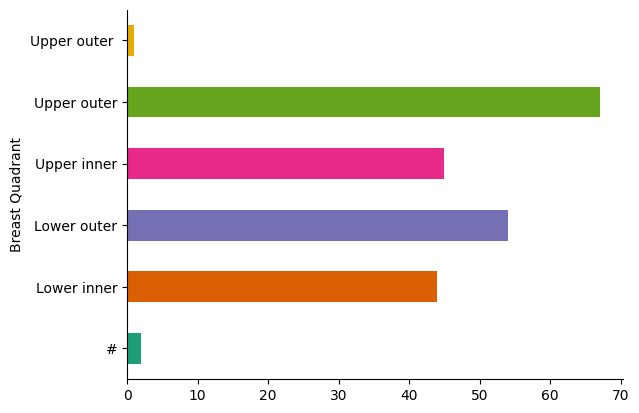

In [ ]:
df.groupby('Breast Quadrant').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.size
print()
df.info()
print()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               213 non-null    int64 
 1   Menopause         213 non-null    int64 
 2   Tumor Size (cm)   213 non-null    object
 3   Breast Quadrant   213 non-null    object
 4   History           213 non-null    object
 5   Diagnosis Result  213 non-null    object
dtypes: int64(2), object(4)
memory usage: 10.1+ KB



,Age,Menopause
count,213.000000,213.000000
mean,39.784038,0.666667
std,14.096712,0.472515
min,13.000000,0.000000
25%,30.000000,0.000000
50%,40.000000,1.000000
75%,49.000000,1.000000
max,77.000000,1.000000


### Data Preprocessing & Features Engineering


In [ ]:
df.columns

Index(['Age', 'Menopause', 'Tumor Size (cm)', 'Breast Quadrant', 'History',
       'Diagnosis Result'],
      dtype='object')

Column: Menopause
Goal: Clean the data and convert it to categorical data

In [ ]:
df['Menopause'].value_counts()

,count
Menopause,
1,142
0,71


In [ ]:
df['Menopause'].dtype

dtype('int64')

In [ ]:
#1= Achieved menopause?
#0= Not achieved meopause?

NewMenopause= pd.Series([1, 0], dtype= "category")
df['NewMenopause']= NewMenopause

df.loc[df["Menopause"] == 1, "NewMenopause"]= NewMenopause[0]
df.loc[df["Menopause"] == 0, "NewMenopause"]= NewMenopause[1]

df.head(20)

,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result,NewMenopause
0,40,1,2,Upper inner,0,Benign,1
1,39,1,2,Upper outer,0,Benign,1
2,45,0,4,Lower outer,0,Benign,0
3,26,1,3,Lower inner,1,Benign,1
4,21,1,1,Upper outer,1,Benign,1
5,50,0,5,Lower outer,0,Malignant,0
6,58,0,6,Upper outer,0,Malignant,0
7,21,1,3,Upper inner,0,Benign,1
8,35,1,4,Upper outer,0,Benign,1
9,42,1,2,Lower outer,1,Benign,1


**Column: Age**

In [ ]:
df['Age'].value_counts().sort_index(ascending= True)

,count
Age,
13,1
14,3
15,2
16,2
17,4
18,6
19,3
20,3
21,5


In [ ]:
NewAge= pd.Series(['Below 20', '20 to 30', '31 to 40', '41 to 50', '51 to 60', 'Above 60'])

def set_age(row):
  if row["Age"] < 20:
    return NewAge[0]
  elif row["Age"] >= 20 and row["Age"] <= 30:
    return NewAge[1]
  elif row["Age"] >= 31 and row["Age"] <= 40:
    return NewAge[2]
  elif row["Age"] >= 41 and row["Age"] <= 60:
    return NewAge[4]
  elif row["Age"] > 60:
    return NewAge[5]
  else:
    return None

df['NewAge']= df.apply(set_age, axis=1)

df.head(10)

,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result,NewMenopause,NewAge
0,40,1,2,Upper inner,0,Benign,1,31 to 40
1,39,1,2,Upper outer,0,Benign,1,31 to 40
2,45,0,4,Lower outer,0,Benign,0,51 to 60
3,26,1,3,Lower inner,1,Benign,1,20 to 30
4,21,1,1,Upper outer,1,Benign,1,20 to 30
5,50,0,5,Lower outer,0,Malignant,0,51 to 60
6,58,0,6,Upper outer,0,Malignant,0,51 to 60
7,21,1,3,Upper inner,0,Benign,1,20 to 30
8,35,1,4,Upper outer,0,Benign,1,31 to 40
9,42,1,2,Lower outer,1,Benign,1,51 to 60


**Column: Breast Quadrant**

My goal is to fill out missing values and encode them as categorical data using one hot encoding.

In [ ]:
df['Breast Quadrant'].value_counts()

,count
Breast Quadrant,
Upper outer,67
Lower outer,54
Upper inner,45
Lower inner,44
#,2
Upper outer,1


In [ ]:
#cleaning up the mistakes in the data entry

df['Breast Quadrant'] = df['Breast Quadrant'].replace({'#': 'Lower outer', 'Upper outer ': 'Upper outer'})
df['Breast Quadrant'].value_counts()


,count
Breast Quadrant,
Upper outer,68
Lower outer,56
Upper inner,45
Lower inner,44


In [ ]:
#Transforming the breast quadrants into categorical data using one-hot encoding

New_BreastQuadrant= pd.Series (['Upper outer', 'Lower outer', 'Upper inner', 'Lower inner'], dtype= "category")
df['New_BreastQuadrant']= New_BreastQuadrant

def set_breastquadrant(row):
  if row["Breast Quadrant"] == 'Upper outer':
    return New_BreastQuadrant[0]
  elif row["Breast Quadrant"] == 'Lower outer':
    return New_BreastQuadrant[1]
  elif row["Breast Quadrant"] == 'Upper inner':
    return New_BreastQuadrant[2]
  elif row["Breast Quadrant"] == 'Lower inner':
    return New_BreastQuadrant[3]
  else:
    return None

df['New_BreastQuadrant']= df.apply(set_breastquadrant, axis= 1)

df.head()







,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result,NewMenopause,NewAge,New_BreastQuadrant
0,40,1,2,Upper inner,0,Benign,1,31 to 40,Upper inner
1,39,1,2,Upper outer,0,Benign,1,31 to 40,Upper outer
2,45,0,4,Lower outer,0,Benign,0,51 to 60,Lower outer
3,26,1,3,Lower inner,1,Benign,1,20 to 30,Lower inner
4,21,1,1,Upper outer,1,Benign,1,20 to 30,Upper outer


**Column: Tumour Size**

The goal is to clean up the tumour size values scale the tumour size so outliers do not affect the distribution.


In [ ]:
#Cleaning up the data under tumour size
df['Tumor Size (cm)'] = df['Tumor Size (cm)'].replace({'#': '3'})
df['Tumor Size (cm)'].value_counts()


,count
Tumor Size (cm),
3,35
2,32
4,32
1,29
5,27
6,17
7,14
8,11
10,7


**Column: History**
Clean up the history column and convert the values to categorical data

In [ ]:
df['History'].value_counts()

,count
History,
0,124
1,87
#,2


In [ ]:
df['History']= df['History'].replace ({'#': 0} or {'#': '0'})
df['History'].value_counts()

,count
History,
0,124
1,87
0,2


In [ ]:
df['History'].dtype

dtype('O')

In [ ]:
NewHistory = pd.Series([0, 1], dtype= 'category')

def set_history(row):
  if row['History']== 0 or row['History']== '0':
    return NewHistory[0]
  elif row['History']== 1 or row['History']== '1':
    return NewHistory[1]
  else:
    return None

df['NewHistory']= df.apply(set_history, axis=1)

df.head()

,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result,NewMenopause,NewAge,New_BreastQuadrant,NewHistory
0,40,1,2,Upper inner,0,Benign,1,31 to 40,Upper inner,0
1,39,1,2,Upper outer,0,Benign,1,31 to 40,Upper outer,0
2,45,0,4,Lower outer,0,Benign,0,51 to 60,Lower outer,0
3,26,1,3,Lower inner,1,Benign,1,20 to 30,Lower inner,1
4,21,1,1,Upper outer,1,Benign,1,20 to 30,Upper outer,1


**Column: Diagnosis Result**
Goal: Clean up thhis column and convert it into categorical data

In [ ]:
df['Diagnosis Result'].value_counts()

,count
Diagnosis Result,
Benign,120
Malignant,93


In [ ]:
NewDiagnosis= pd.Series(['Benign', 'Malignant'], dtype= "category")

def set_diagnosis(row):
  if row['Diagnosis Result']== 'Benign':
    return NewDiagnosis[0]
  elif row['Diagnosis Result']== 'Malignant':
    return NewDiagnosis[1]
  else:
    return None

df['NewDiagnosis']= df.apply(set_diagnosis, axis=1)

df.head()

,Age,Menopause,Tumor Size (cm),Breast Quadrant,History,Diagnosis Result,NewMenopause,NewAge,New_BreastQuadrant,NewHistory,NewDiagnosis
0,40,1,2,Upper inner,0,Benign,1,31 to 40,Upper inner,0,Benign
1,39,1,2,Upper outer,0,Benign,1,31 to 40,Upper outer,0,Benign
2,45,0,4,Lower outer,0,Benign,0,51 to 60,Lower outer,0,Benign
3,26,1,3,Lower inner,1,Benign,1,20 to 30,Lower inner,1,Benign
4,21,1,1,Upper outer,1,Benign,1,20 to 30,Upper outer,1,Benign


In [ ]:
#Convert Tumour sizes to numerical data type

df['Tumor Size (cm)'] = pd.to_numeric(df['Tumor Size (cm)'], errors='coerce')


In [ ]:
df['Tumor Size (cm)'].dtype

dtype('int64')

### Convert the Columns using one hot encoder

In [ ]:
cat_df = df[['Tumor Size (cm)', 'NewMenopause', 'NewAge', 'New_BreastQuadrant', 'NewHistory', 'NewDiagnosis']]

# Then apply pd.get_dummies on cat_df
final_df = pd.get_dummies(cat_df, columns=['NewMenopause', 'NewAge', 'New_BreastQuadrant', 'NewHistory', 'NewDiagnosis'], drop_first=True)
final_df.head()

,Tumor Size (cm),NewMenopause_1,NewAge_31 to 40,NewAge_51 to 60,NewAge_Above 60,NewAge_Below 20,New_BreastQuadrant_Lower outer,New_BreastQuadrant_Upper inner,New_BreastQuadrant_Upper outer,NewHistory_1,NewDiagnosis_Malignant
0,2,True,True,False,False,False,False,True,False,False,False
1,2,True,True,False,False,False,False,False,True,False,False
2,4,False,False,True,False,False,True,False,False,False,False
3,3,True,False,False,False,False,False,False,False,True,False
4,1,True,False,False,False,False,False,False,True,True,False


In [ ]:
df.columns

Index(['Age', 'Menopause', 'Tumor Size (cm)', 'Breast Quadrant', 'History',
       'Diagnosis Result', 'NewMenopause', 'NewAge', 'New_BreastQuadrant',
       'NewHistory', 'NewDiagnosis'],
      dtype='object')

In [ ]:
cat_df['Tumor Size (cm)'].unique()

array([ 2,  4,  3,  1,  5,  6,  7, 10,  8,  9, 14, 12])

## Model Training

In [ ]:
#Splitting the data into test and train data.

x = final_df.drop('NewDiagnosis_Malignant', axis=1)
y = final_df['NewDiagnosis_Malignant']

## Training With Logistic regression

In [ ]:

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 0)
log_reg= LogisticRegression()
log_reg.fit(x_train, y_train)

LogisticRegression()

In [ ]:
accuracy_score(y_train, log_reg.predict(x_train))


0.8764705882352941

In [ ]:
accuracy_score(y_test, log_reg.predict(x_test))

0.8604651162790697

In [ ]:
confusion_matrix(y_test, log_reg.predict(x_test))

array([[24,  3],
       [ 3, 13]])

In [ ]:
print(classification_report(y_test, log_reg.predict(x_test)))

              precision    recall  f1-score   support

       False       0.89      0.89      0.89        27
        True       0.81      0.81      0.81        16

    accuracy                           0.86        43
   macro avg       0.85      0.85      0.85        43
weighted avg       0.86      0.86      0.86        43



## Training with K-Nearest Neighbor

In [ ]:
#I chose hamming as the metric because most of the data in the datset are categorical data

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 0)
knn= KNeighborsClassifier(n_neighbors= 4, metric= 'hamming')
knn.fit(x_train, y_train)



KNeighborsClassifier(metric='hamming', n_neighbors=4)

In [ ]:
#Checking for the accuracy score
accuracy_score(y_train, knn.predict(x_train))

0.788235294117647

In [ ]:
y_pred= knn.predict(x_test)
accuracy_score(y_test, y_pred)

0.7674418604651163

In [ ]:
print (classification_report (y_test, knn.predict (x_test)))

              precision    recall  f1-score   support

       False       0.73      1.00      0.84        27
        True       1.00      0.38      0.55        16

    accuracy                           0.77        43
   macro avg       0.86      0.69      0.69        43
weighted avg       0.83      0.77      0.73        43



## Train with SUpport Vector Classifier

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 0)

svc= SVC(probability= True)

parameter= {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.01, 0.05, 0.5, 0.01, 1, 10, 15, 20]
}

gridsearch= GridSearchCV(svc, parameter, cv= 5, scoring= 'accuracy')
gridsearch.fit (x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [0.01, 0.05, 0.5, 0.01, 1, 10, 15, 20],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

In [ ]:
gridsearch.best_params_

{'C': 0.05, 'kernel': 'linear'}

In [ ]:
gridsearch.best_score_


#The recall score is 79%. This is an acceptable score because the cost of a false negative would be very serious
#The precision is 98% which is acceptable because it's important to identify positives.
#The accuracy score is 90%

0.9

## Training the Model with Random Forest

In [ ]:

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state= 0)
rf= RandomForestClassifier(random_state= 0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)

rf.fit(x_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
best_parameters= grid_search.best_params_
print (best_parameters)

{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


In [ ]:
accuracy_score(y_train, rf.predict(x_train))

0.9705882352941176

In [ ]:
accuracy_score(y_test,  rf.predict(x_test))

0.8604651162790697

Saving the file so I can deploy locally

In [ ]:
import joblib
joblib.dump(log_reg, 'log_reg.pkl')
joblib.dump(knn, 'knn.pkl')
joblib.dump(rf, 'rf.pkl')
joblib.dump(gridsearch, 'svc.pkl')


['svc.pkl']

In [ ]:
from google.colab import files
files.download('log_reg.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#files.download ('knn.pkl')

In [ ]:
#files.download ('rf.pkl')